In [2]:
import os

import your

import time
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, classification_report, confusion_matrix, precision_recall_fscore_support

from matplotlib.colors import ListedColormap

from astropy import units as u

from tqdm import tqdm

from pathlib import Path

In [3]:
# Пути к твоим файлам
meta_path  = "B0531+21_59000_48386_subset_channels_meta.csv"
x_path     = "B0531+21_59000_48386_subset_channels.npy"
split_path = "split_indices.npz"

meta = pd.read_csv(meta_path).fillna("None")
X = np.load(x_path)  # ожидаем (N,256) или (N,1,256)
splits = np.load(split_path)

train_idx = splits["train_idx"]
val_idx   = splits["val_idx"]
test_idx  = splits["test_idx"]

# бинарные метки: NBRFI=1, None=0
y = (meta["label"].values == "NBRFI").astype(np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape, "classes:", np.unique(y, return_counts=True))
print("train/val/test:", len(train_idx), len(val_idx), len(test_idx))


X shape: (20000, 256)
y shape: (20000,) classes: (array([0, 1]), array([10000, 10000]))
train/val/test: 16000 2000 2000


In [4]:
class Simple1DDataset(Dataset):
    def __init__(self, X, y, indices, normalize=True):
        self.X = X
        self.y = y
        self.indices = indices
        self.normalize = normalize

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx = self.indices[i]
        x = self.X[idx]

        # приводим к (1,256)
        if x.ndim == 1:
            x = x[None, :]              # (1,256)
        elif x.ndim == 2 and x.shape[0] != 1:
            # если вдруг (256,1) — на всякий случай
            x = x.T

        x = x.astype(np.float32)

        if self.normalize:
            m = x.max()
            if m < 1e-8:
                m = 1.0
            x = x / m

        x = torch.from_numpy(x)  # (1,256)
        y = torch.tensor([self.y[idx]], dtype=torch.float32)  # (1,)

        return x, y


In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

batch_size = 256  # если будет OOM — уменьши до 128/64

train_ds = Simple1DDataset(X, y, train_idx, normalize=True)
val_ds   = Simple1DDataset(X, y, val_idx,   normalize=True)
test_ds  = Simple1DDataset(X, y, test_idx,  normalize=True)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False)


device: cuda


In [6]:
class CNN1D_RFI_256_logits(nn.Module):
    """
    Input:  (N, 1, 256)
    Output: (N, 1)  (logits)
    """
    def __init__(self, dropout=0.5):
        super().__init__()

        self.conv1 = nn.Conv1d(1, 64, 7)        # 256 -> 250
        self.pool1 = nn.MaxPool1d(2, 2)         # 250 -> 125
        self.conv2 = nn.Conv1d(64, 128, 7)      # 125 -> 119
        self.pool2 = nn.MaxPool1d(2, 2)         # 120 -> 60 (после pad)
        self.conv3 = nn.Conv1d(128, 256, 10)    # 60 -> 51
        self.pool3 = nn.MaxPool1d(2, 2)         # 51 -> 25

        self.fc1 = nn.Linear(6400, 256)         # 25*256=6400
        self.drop = nn.Dropout(dropout)
        self.fc2 = nn.Linear(256, 1)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)

        x = F.relu(self.conv2(x))
        x = F.pad(x, (0, 1))
        x = self.pool2(x)

        x = F.relu(self.conv3(x))
        x = self.pool3(x)

        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        logits = self.fc2(x)
        return logits


model = CNN1D_RFI_256_logits(dropout=0.5).to(device)

loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [7]:
def run_one_epoch(model, loader, training: bool):
    if training:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for x, yb in loader:
        x = x.to(device)
        yb = yb.to(device)  # (B,1)

        if training:
            optimizer.zero_grad()

        with torch.set_grad_enabled(training):
            logits = model(x)                 # (B,1)
            loss = loss_fn(logits, yb)

            if training:
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * x.size(0)

        # accuracy
        probs = torch.sigmoid(logits)
        preds = (probs >= 0.5).float()
        correct += (preds == yb).sum().item()
        total += yb.numel()

    avg_loss = total_loss / len(loader.dataset)
    acc = correct / total
    return avg_loss, acc

In [21]:
best_val_acc = -1.0
best_path = "best_model_by_acc.pt"

epochs = 50

train_losses, val_losses = [], []
train_accs, val_accs = [], []

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = run_one_epoch(model, train_loader, training=True)
    va_loss, va_acc = run_one_epoch(model, val_loader, training=False)

    train_losses.append(tr_loss)
    val_losses.append(va_loss)
    train_accs.append(tr_acc)
    val_accs.append(va_acc)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f}")

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_acc": best_val_acc,
            "val_loss": va_loss,
        }, best_path)
        print(f"  ✅ Saved best model to {best_path} (val acc={best_val_acc:.4f})")

Epoch 01 | train loss 0.5259 acc 0.7249 | val loss 0.3135 acc 0.8735
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.8735)
Epoch 02 | train loss 0.3160 acc 0.8694 | val loss 0.2703 acc 0.8920
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.8920)
Epoch 03 | train loss 0.2992 acc 0.8774 | val loss 0.2693 acc 0.8880
Epoch 04 | train loss 0.3012 acc 0.8741 | val loss 0.2430 acc 0.9030
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.9030)
Epoch 05 | train loss 0.2645 acc 0.8961 | val loss 0.2448 acc 0.9040
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.9040)
Epoch 06 | train loss 0.2716 acc 0.8936 | val loss 0.2371 acc 0.9060
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.9060)
Epoch 07 | train loss 0.2629 acc 0.8988 | val loss 0.2332 acc 0.9100
  ✅ Saved best model to best_model_by_acc.pt (val acc=0.9100)
Epoch 08 | train loss 0.2596 acc 0.8981 | val loss 0.2646 acc 0.8940
Epoch 09 | train loss 0.2586 acc 0.8977 | val loss 0.2346 acc 0.9070
Epoch 1

In [22]:
test_loss, test_acc = run_one_epoch(model, test_loader, training=False)
print(f"TEST | loss {test_loss:.4f} acc {test_acc:.4f}")


TEST | loss 0.2185 acc 0.9155


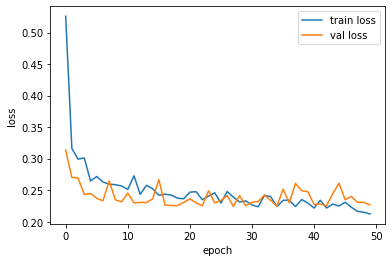

In [23]:
plt.figure()
plt.plot(train_losses, label="train loss")
plt.plot(val_losses, label="val loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend()
# plt.show()


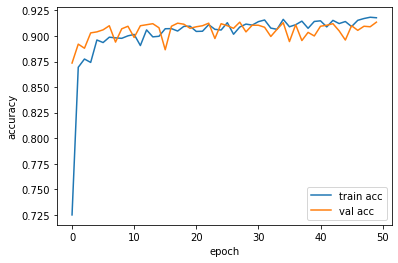

In [24]:
plt.figure()
plt.plot(train_accs, label="train acc")
plt.plot(val_accs, label="val acc")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.legend()
# plt.show()

## Test os saved model on new data

In [8]:
def get_data_from_filterbank(filterbank_file, index, rand=0):
    steps = range(0, filterbank_file.your_header.nspectra, 256)
    return filterbank_file.get_data(nstart=steps[index]+rand, nsamp=256).T

In [9]:
ckpt = torch.load("best_model_by_acc.pt", map_location=device)

model = CNN1D_RFI_256_logits(dropout=0.5).to(device)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CNN1D_RFI_256_logits(
  (conv1): Conv1d(1, 64, kernel_size=(7,), stride=(1,))
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv1d(64, 128, kernel_size=(7,), stride=(1,))
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(128, 256, kernel_size=(10,), stride=(1,))
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=6400, out_features=256, bias=True)
  (drop): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=256, out_features=1, bias=True)
)

In [10]:
filterbank_file_path = '/hercules/results/akazantsev/filterbank_files/B0531+21/B0531+21_59000_48386.fil'


frequency_range = {
    'B0531+21_59000_48386.fil': np.linspace(1530.0, 1210.0, 256)
}

rfi_blocks = {
    'B0531+21_59000_48386.fil': {
        1: (204,1527,),
        2: (2023, 4436,),
        3: (4437, 4953,),
        4: (6701, 7631,),
        5: (42546, 45015,),
        6: (45622, 45705,),
        7: (46186, 46927,),
        8: (46928, 47303,),
        9: (48686, 48831,),
        10: (48832, 49591,)
    }
}

In [14]:
filterbank_file = your.Your(filterbank_file_path) 
f_first = filterbank_file.your_header.fch1 * u.megahertz
f_last  = (filterbank_file.your_header.fch1 + filterbank_file.your_header.bw) * u.megahertz
tsamp = filterbank_file.your_header.tsamp * u.second

In [16]:
def preprocess_one(x_np, normalize=True):
    x = x_np
    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim == 2 and x.shape[0] != 1:
        x = x.T

    x = x.astype(np.float32)

    if normalize:
        m = x.max()
        if m < 1e-8:
            m = 1.0
        x = x / m

    x = torch.from_numpy(x)      # (1,256)
    x = x.unsqueeze(0)           # (1,1,256) добавили batch
    return x

@torch.no_grad()
def predict_one(x_np):
    model.eval()
    x = preprocess_one(x_np, normalize=True).to(device)
    logits = model(x)
    prob = torch.sigmoid(logits).item()
    pred = int(prob >= 0.9)
    return pred, prob


def plot_spec_with_mask(
    filterbank_file,
    index,
    predict_one,          # <- функция предсказания одной строки: pred, prob = predict_one(row)
    title_name="",
    addition_to_title="",
    plot=False,
    save=False,
    out_dir='',
    random_shift=False,
    random_seed=42,
):
    """
    predict_one(row) должен возвращать:
      pred: 0/1 (или bool/инт) — предсказанный класс для строки
      prob: float — вероятность/скор (может быть None, тогда вернём NaN)
    """
    data = get_data_from_filterbank(filterbank_file, index)  # (H, W)
    dy = dx = 0

    rng = np.random.default_rng(random_seed)
    if random_shift:
        dy = int(rng.integers(50, 150))
        dx = int(rng.integers(50, 150))
        data = np.roll(data, shift=(dy, dx), axis=(0, 1))

    H, W = data.shape

    # Предсказываем по каждой строке: mask + probs
    mask = np.zeros(H, dtype=bool)
    probs = np.full(H, np.nan, dtype=float)

    for i, row in enumerate(data):
        pred, prob = predict_one(row)
        mask[i] = (int(pred) == 1)
        if prob is not None:
            probs[i] = float(prob)

    row_mask = mask
    overlay = np.repeat(row_mask[:, None], W, axis=1).astype(float)

    cmap_black = ListedColormap([(0, 0, 0, 0.0), (0, 0, 0, 1.0)])
    vmin, vmax = float(np.min(data)), float(np.max(data))

    extent = [0, W, float(f_last.value), float(f_first.value)]

    if plot:
        plt.clf()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
        fig.suptitle(
            f"Index {index} | Model: {title_name}\nShift: dx={dx}, dy={dy}{addition_to_title}",
            fontsize=13
        )

        ax1.imshow(data, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="auto", origin="upper")
        ax1.set_title("Original")
        ax1.set_xlabel(f"Time samples (dt={tsamp.to(u.microsecond):.1f})")
        ax1.set_ylabel("Frequency")

        ax2.imshow(data, cmap="gray", vmin=vmin, vmax=vmax, extent=extent, aspect="auto", origin="upper")
        ax2.imshow(overlay, cmap=cmap_black, vmin=0, vmax=1, extent=extent, aspect="auto", origin="upper")
        ax2.set_title("With mask")
        ax2.set_xlabel(f"Time samples (dt={tsamp.to(u.microsecond):.1f})")

        plt.tight_layout()

        if save:
            Path(out_dir).mkdir(parents=True, exist_ok=True)
            out = f"{out_dir}{os.sep}spec_with_mask_idx_{index}_dx_{dx}_dy_{dy}.png"
            plt.savefig(out, dpi=250)
            #print("Saved:", out)
        else:
            plt.show()

    return row_mask, probs

In [30]:
meta_csv_path = 'B0531+21_59000_48386_channels_meta.csv'
meta = pd.read_csv(meta_csv_path)
meta = meta.fillna("None")

<ipython-input-30-7cb30cfa5d10>:2: DtypeWarning: Columns (21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(meta_csv_path)


In [14]:
meta.head()

,sample_index,global_index,segment_index,channel_index,frequency,mean_o,std_o,skew_o,kurt_o,mean_n,...,mean_o_ratio,std_o_ratio,skew_o_ratio,kurt_o_ratio,mean_n_ratio,std_n_ratio,skew_n_ratio,kurt_n_ratio,label,original_segment_label
0,0,0,0,0,1530.000000,128.359375,21.264052,0.114631,-0.140737,122.070175,...,1.007947,1.002565,0.701702,-3.980736,1.019578,1.006820,0.676858,1.575076,None,None
1,1,0,0,1,1528.745098,128.261719,20.569192,0.199155,-0.028248,146.817460,...,1.007180,0.969804,1.219106,-0.799001,1.226277,0.881165,1.175943,0.316145,None,None
2,2,0,0,2,1527.490196,127.324219,21.419552,0.365953,0.379996,117.855932,...,0.999819,1.009897,2.240143,10.748126,0.984379,0.979803,2.160830,-4.252761,None,None
3,3,0,0,3,1526.235294,127.824219,23.605902,-0.004858,-0.065768,123.508065,...,1.003745,1.112980,-0.029736,-1.860230,1.031588,1.027565,-0.028684,0.736046,None,None
4,4,0,0,4,1524.980392,130.824219,21.604496,-0.174239,-0.384922,131.054054,...,1.027302,1.018617,-1.066585,-10.887461,1.094615,1.050586,-1.028822,4.307892,None,None


In [15]:
train_idx

array([ 6993,  9182, 10109, ...,  9814,   428,  7470])

In [16]:
val_idx

array([14856, 10296,  4674, ...,  9913,   731, 15974])

In [17]:
test_idx

array([ 9437,  8948, 13786, ...,  8347,  4258,  5287])

In [18]:
# объединяем все использованные sample_index
used_idx = np.concatenate([train_idx, val_idx, test_idx])

# 2) маска неиспользованных sample_index (сравниваем как строки, чтобы не споткнуться о типы)
unused_mask = ~meta["sample_index"].astype(str).isin(used_idx.astype(str))

# 3) срез неиспользованных
unused = meta.loc[unused_mask, ["segment_index", "label"]].copy()
unused["label"] = unused["label"].astype(str)

unused_segments_by_label = (
    unused.groupby("label")["segment_index"]
          .unique()
          .apply(list)
          .to_dict()
)

unused_segment_nbrfi = unused_segments_by_label.get("NBRFI", [])
unused_segment_none  = unused_segments_by_label.get("None", [])

In [19]:
nbrfi_idx = np.random.choice(unused_segment_nbrfi)

In [20]:
none_idx = np.random.choice(unused_segment_none)

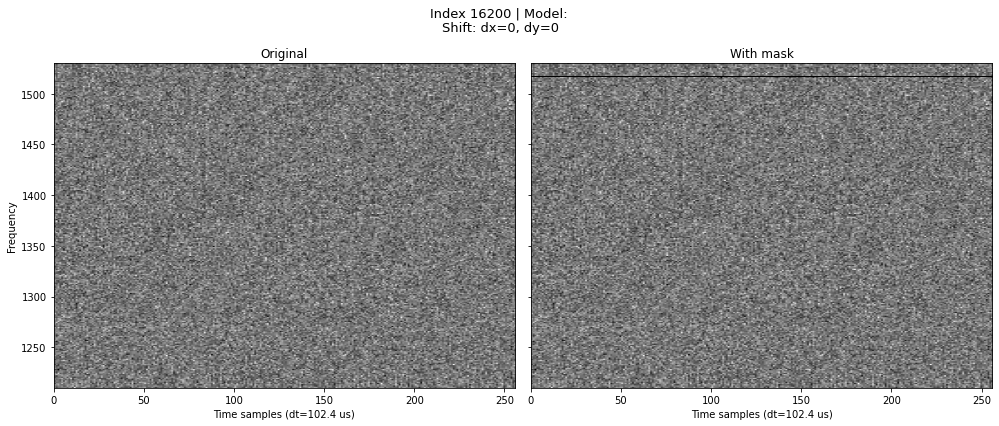

In [31]:
_, _ = plot_spec_with_mask(filterbank_file, 16200, predict_one, plot=True, save=False)

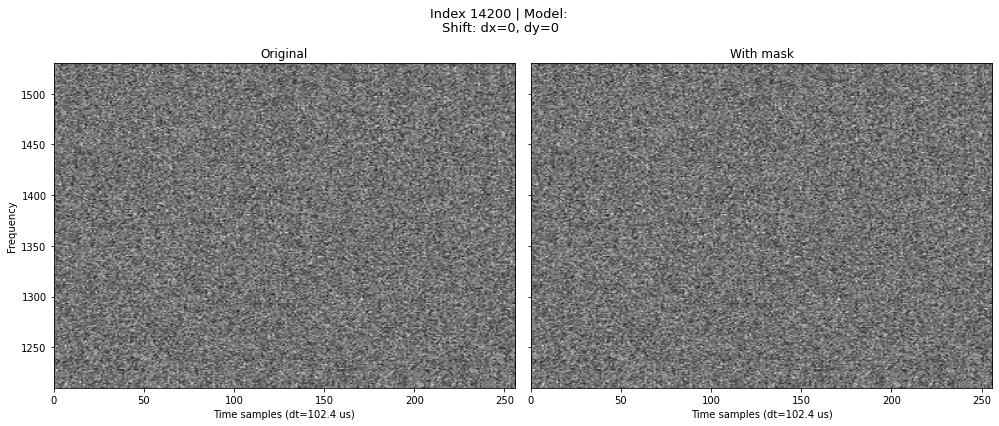

In [32]:
_, _ = plot_spec_with_mask(filterbank_file, 14200, predict_one, plot=True, save=False)

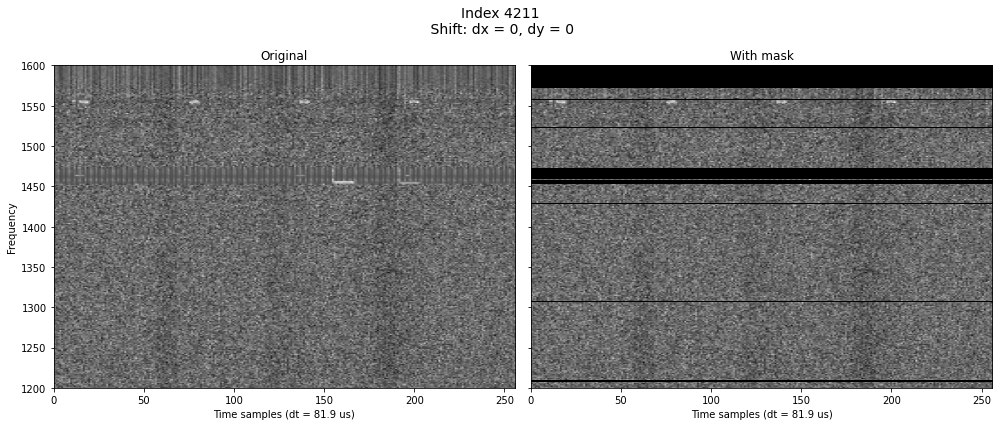

In [228]:
plot_spec_with_mask(filterbank_file, 4211, save=False)

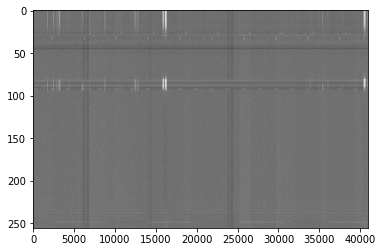

In [226]:
plt.clf()
plt.imshow(filterbank_file.get_data(nstart=2048*410, nsamp=2048*20).T, cmap='gray', aspect='auto')
plt.show()

## Global key metrics calculation via average individual segments metrics

In [33]:
meta_csv_path = 'B0531+21_59000_48386_channels_meta.csv'
meta = pd.read_csv(meta_csv_path)
meta = meta.fillna("None")

<ipython-input-33-7cb30cfa5d10>:2: DtypeWarning: Columns (21,22) have mixed types. Specify dtype option on import or set low_memory=False.
  meta = pd.read_csv(meta_csv_path)


In [34]:
# объединяем все использованные sample_index
used_idx = np.concatenate([train_idx, val_idx, test_idx])

# 2) маска неиспользованных sample_index (сравниваем как строки, чтобы не споткнуться о типы)
unused_mask = ~meta["sample_index"].astype(str).isin(used_idx.astype(str))

# 3) срез неиспользованных
unused = meta.loc[unused_mask, ["segment_index", "label"]].copy()
unused["label"] = unused["label"].astype(str)

unused_segments_by_label = (
    unused.groupby("label")["segment_index"]
          .unique()
          .apply(list)
          .to_dict()
)

unused_segment_nbrfi = unused_segments_by_label.get("NBRFI", [])
unused_segment_none  = unused_segments_by_label.get("None", [])

print(len(unused_segment_none), len(unused_segment_nbrfi))

21095 5483


In [35]:
individual_key_metrics_segment_none = pd.DataFrame(columns=['segment_index', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'precision', 'recall', 'fscore'])

In [42]:
for idx, segment_index in enumerate(unused_segment_none):
    row_mask, probs = plot_spec_with_mask(
        filterbank_file,
        index=segment_index,
        predict_one=predict_one,          # <- функция предсказания одной строки: pred, prob = predict_one(row)
        title_name="",
        plot=False,
        save=False,
        random_shift=False,
        random_seed=False,
    )
    mask = meta['segment_index'].eq(segment_index)
    y = meta.loc[mask, 'label'].eq('NBRFI').astype(int)
    y_true = np.array(y)
    y_pred = row_mask.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = round(accuracy_score(y_true, y_pred), 4)
    
    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary",   # метрики только для pos_label
        pos_label=1,
        zero_division=0     # что делать при 0/0
    )
    precision = round(precision, 4)
    recall = round(recall, 4)
    fscore = round(fscore, 4)

    individual_key_metrics_segment_none.loc[idx] = [segment_index, tn, fp, fn, tp, accuracy, precision, recall, fscore]

In [43]:
individual_key_metrics_segment_none.head()

,segment_index,TN,FP,FN,TP,accuracy,precision,recall,fscore
0,8776.0,255.0,1.0,0.0,0.0,0.9961,0.0,0.0,0.0
1,8777.0,256.0,0.0,0.0,0.0,1.0000,0.0,0.0,0.0
2,8778.0,256.0,0.0,0.0,0.0,1.0000,0.0,0.0,0.0
3,8779.0,253.0,3.0,0.0,0.0,0.9883,0.0,0.0,0.0
4,8780.0,256.0,0.0,0.0,0.0,1.0000,0.0,0.0,0.0


In [47]:
individual_key_metrics_segment_nbrfi = pd.DataFrame(columns=['segment_index', 'TN', 'FP', 'FN', 'TP', 'accuracy', 'precision', 'recall', 'fscore'])

In [50]:
for idx, segment_index in enumerate(tqdm(unused_segment_nbrfi, total=len(unused_segment_nbrfi))):
    row_mask, probs = plot_spec_with_mask(
        filterbank_file,
        index=segment_index,
        predict_one=predict_one,          # <- функция предсказания одной строки: pred, prob = predict_one(row)
        title_name="",
        plot=False,
        save=False,
        random_shift=False,
        random_seed=False,
    )
    mask = meta['segment_index'].eq(segment_index)
    y = meta.loc[mask, 'label'].eq('NBRFI').astype(int)
    y_true = np.array(y)
    y_pred = row_mask.astype(int)

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    accuracy = round(accuracy_score(y_true, y_pred), 4)
    
    precision, recall, fscore, _ = precision_recall_fscore_support(
        y_true, y_pred,
        average="binary",   # метрики только для pos_label
        pos_label=1,
        zero_division=0     # что делать при 0/0
    )
    precision = round(precision, 4)
    recall = round(recall, 4)
    fscore = round(fscore, 4)

    individual_key_metrics_segment_nbrfi.loc[idx] = [segment_index, tn, fp, fn, tp, accuracy, precision, recall, fscore]

100%|██████████| 5483/5483 [45:10<00:00,  2.02it/s]


In [51]:
individual_key_metrics_segment_nbrfi.head()

,segment_index,TN,FP,FN,TP,accuracy,precision,recall,fscore
0,223.0,244.0,3.0,5.0,4.0,0.9688,0.5714,0.4444,0.5000
1,224.0,245.0,2.0,6.0,3.0,0.9688,0.6000,0.3333,0.4286
2,225.0,245.0,2.0,6.0,3.0,0.9688,0.6000,0.3333,0.4286
3,226.0,244.0,3.0,5.0,4.0,0.9688,0.5714,0.4444,0.5000
4,227.0,246.0,1.0,4.0,5.0,0.9805,0.8333,0.5556,0.6667


In [52]:
def plot_hists_simple(df: pd.DataFrame, cols=None, bins=30, ncols=3):
    d = df.copy().apply(pd.to_numeric, errors="coerce")

    if cols is None:
        cols = list(d.columns)
    else:
        cols = [c for c in cols if c in d.columns]

    n = len(cols)
    if n == 0:
        print("Нечего рисовать: cols пустой или колонок нет в df.")
        return

    nrows = math.ceil(n / ncols)
    plt.figure(figsize=(4 * ncols, 3 * nrows))

    for i, col in enumerate(cols, start=1):
        plt.subplot(nrows, ncols, i)
        x = d[col].dropna().values

        if x.size == 0:
            plt.title(col)
            plt.text(0.5, 0.5, "empty", ha="center", va="center", transform=plt.gca().transAxes)
            plt.axis("off")
            continue

        plt.hist(x, bins=bins)

        mean_val = float(np.mean(x))
        median_val = float(np.median(x))

        # обе линии чёрные
        plt.axvline(mean_val, color="black", linestyle="-", linewidth=2, label=f"mean={mean_val:.4g}")
        plt.axvline(median_val, color="black", linestyle="--", linewidth=2, label=f"median={median_val:.4g}")

        plt.title(col)
        plt.xlabel(col)
        plt.ylabel("count")
        plt.grid(True, ls="--")
        plt.legend()

    plt.tight_layout()
    plt.show()

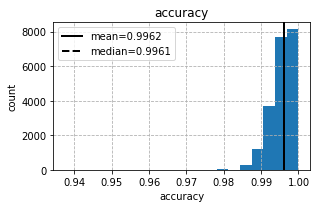

In [58]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['accuracy'], bins=20)

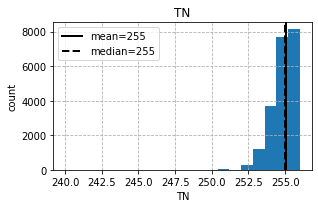

In [59]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['TN'], bins=20)

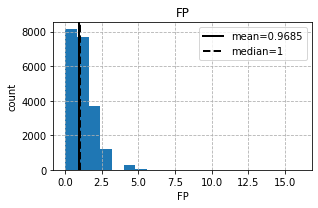

In [60]:
plot_hists_simple(individual_key_metrics_segment_none, cols=['FP'], bins=20)

In [5]:
----

SyntaxError: invalid syntax (2133496677.py, line 1)

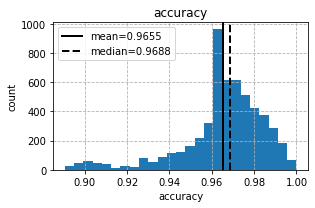

In [61]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['accuracy'], bins=25)

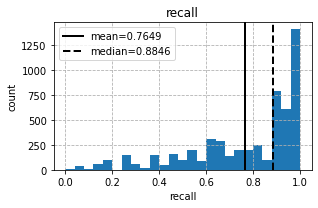

In [62]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['recall'], bins=25)

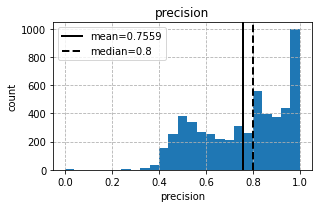

In [63]:
plot_hists_simple(individual_key_metrics_segment_nbrfi, cols=['precision'], bins=25)

In [ ]:
metric = 'precision'
upper_limit = 0.8

table = individual_key_metrics_segment_nbrfi[individual_key_metrics_segment_nbrfi[metric] <= upper_limit]

out_dir = f"1_cnn_individual_key_metrics_segment_nbrf_{metric}_leq_{upper_limit}"

for row in tqdm(table.itertuples(index=True), total=len(table), desc="Processing"):
    # idx = row.Index  # если нужен индекс датафрейма

    segment_index = int(row.segment_index)

    row_mask, probs = plot_spec_with_mask(
        filterbank_file,
        index=segment_index,
        predict_one=predict_one,          # <- функция предсказания одной строки: pred, prob = predict_one(row)
        title_name='1DCNN',
        addition_to_title=(
            f"\nAcc: {row.accuracy}, P: {row.precision}, R: {row.recall}, F1: {row.fscore}"
        ),
        plot=True,
        save=True,
        out_dir=out_dir,
        random_shift=False,
        random_seed=False,
    )

# Performance measurment 

импорты + бюджет real-time

In [12]:
## Актуально когда зппускаешь на видеокарте


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device:", device)

model = model.to(device)
model.eval()

# для скорости на GPU (опционально)
torch.backends.cudnn.benchmark = True

device: cuda:0


In [20]:
idx = 0
data = get_data_from_filterbank(filterbank_file, idx)   # (H,W) numpy на CPU

# batched инференс (рекомендую)
mask, probs = predict_segment_batched(data, threshold=thr)
print(mask.shape, probs.shape, probs[:5])


(256,) (256,) [0.14043617 0.31463778 0.11291676 0.01034227 0.10349141]


In [21]:
import time
import numpy as np

idx = 0
data = get_data_from_filterbank(filterbank_file, idx)

# warmup
for _ in range(20):
    _ = predict_segment_batched(data, threshold=thr)

# timing
t = []
for _ in range(100):
    t0 = time.perf_counter()
    _ = predict_segment_batched(data, threshold=thr)
    if device.type == "cuda":
        torch.cuda.synchronize()
    t.append(time.perf_counter() - t0)

print("median ms:", np.median(t)*1e3, "p95 ms:", np.percentile(t, 95)*1e3)


median ms: 2.507257740944624 p95 ms: 2.531972900032997


In [22]:
nsamp = 256  # длина сегмента по времени

def tsamp_to_seconds(tsamp):
    # поддержка astropy Quantity и float
    if hasattr(tsamp, "to_value"):
        return float(tsamp.to_value("s"))
    return float(tsamp)

tsamp_sec = tsamp_to_seconds(filterbank_file.your_header.tsamp)
budget_ms = 1e3 * nsamp * tsamp_sec

n_total_segments = filterbank_file.your_header.nspectra // nsamp

print(f"device = {device}")
print(f"tsamp = {tsamp_sec*1e6:.3f} µs")
print(f"Budget per segment = {budget_ms:.3f} ms")
print(f"Total segments = {n_total_segments}")

# Для честного CPU-теста:
device = torch.device("cpu")
model = model.to(device)

device = cuda:0
tsamp = 102.400 µs
Budget per segment = 26.214 ms
Total segments = 50071


быстрые версии preprocess/predict (без лишнего model.eval() в каждом вызове)

Твой predict_one вызывает model.eval() каждый раз — это лишнее. Для бенча лучше один раз:

In [23]:
thr = 0.9  # порог классификации

model.eval()

def preprocess_one_cpu(x_np, normalize=True):
    x = x_np
    if x.ndim == 1:
        x = x[None, :]
    elif x.ndim == 2 and x.shape[0] != 1:
        x = x.T

    x = x.astype(np.float32, copy=False)

    if normalize:
        m = float(x.max())
        if m < 1e-8:
            m = 1.0
        x = x / m

    x = torch.from_numpy(x)    # (1,256)
    x = x.unsqueeze(0)         # (1,1,256)
    return x

@torch.no_grad()
def predict_one_fast(x_np, threshold=thr):
    x = preprocess_one_cpu(x_np, normalize=True).to(device, non_blocking=True)
    logits = model(x)
    prob = torch.sigmoid(logits).item()
    pred = int(prob >= threshold)
    return pred, prob


батч-инференс “весь сегмент за один forward”

Это сильно уменьшает Python-overhead (важно и для CPU, и особенно для GPU).

In [24]:
def preprocess_segment_batch(data_hw: np.ndarray, normalize=True):
    """
    data_hw: (H, W) numpy
    вернёт torch tensor: (H, 1, W)
    normalize=True: нормализация по max каждой строки (как в preprocess_one)
    """
    x = np.asarray(data_hw, dtype=np.float32)

    if normalize:
        # max по каждой строке
        m = x.max(axis=1, keepdims=True)
        m = np.where(m < 1e-8, 1.0, m)
        x = x / m

    xt = torch.from_numpy(x)      # (H, W)
    xt = xt.unsqueeze(1)          # (H, 1, W)
    return xt

@torch.no_grad()
def predict_segment_batched(data_hw: np.ndarray, threshold=thr):
    """
    Возвращает:
      mask: (H,) bool
      probs: (H,) float
    """
    x = preprocess_segment_batch(data_hw, normalize=True).to(device, non_blocking=True)

    logits = model(x)                          # ожидаем (H,1) или (H,)
    probs_t = torch.sigmoid(logits).view(-1)   # (H,)
    probs = probs_t.detach().cpu().numpy()
    mask = probs >= threshold
    return mask, probs


тайминг с breakdown по компонентам (LOAD / preprocess / forward / post)

⚠️ Для CPU torch.cuda.synchronize() не нужно. Но я добавлю “на будущее”: если поставишь GPU — просто заработает корректно.

In [25]:
def maybe_sync():
    if torch.cuda.is_available() and str(device).startswith("cuda"):
        torch.cuda.synchronize()

def get_segment_data(filterbank_file, index):
    # используем твою функцию, чтобы замер был "как в твоём пайплайне"
    return get_data_from_filterbank(filterbank_file, index)  # (H,W)

def infer_rowwise_timed(data_hw, threshold=thr):
    """
    Как у тебя: 256 раз predict_one_fast(row)
    Возвращает: mask, probs, times(dict)
    """
    H, W = data_hw.shape
    mask = np.zeros(H, dtype=bool)
    probs = np.full(H, np.nan, dtype=float)

    t_pre = 0.0
    t_fwd = 0.0
    t_post = 0.0

    for i, row in enumerate(data_hw):
        # preprocess
        a0 = time.perf_counter()
        x = preprocess_one_cpu(row, normalize=True).to(device, non_blocking=True)
        a1 = time.perf_counter()
        t_pre += (a1 - a0)

        # forward
        b0 = time.perf_counter()
        maybe_sync()
        logits = model(x)
        maybe_sync()
        prob = torch.sigmoid(logits).item()
        b1 = time.perf_counter()
        t_fwd += (b1 - b0)

        # post
        c0 = time.perf_counter()
        pred = int(prob >= threshold)
        mask[i] = (pred == 1)
        probs[i] = float(prob)
        c1 = time.perf_counter()
        t_post += (c1 - c0)

    times = {"preprocess": t_pre, "forward": t_fwd, "post": t_post, "infer_total": t_pre + t_fwd + t_post}
    return mask, probs, times

def infer_batched_timed(data_hw, threshold=thr):
    """
    Батч: один forward на весь сегмент
    """
    t = {}
    H, W = data_hw.shape

    a0 = time.perf_counter()
    x = preprocess_segment_batch(data_hw, normalize=True).to(device, non_blocking=True)
    a1 = time.perf_counter()
    t["preprocess"] = a1 - a0

    b0 = time.perf_counter()
    maybe_sync()
    logits = model(x)
    maybe_sync()
    probs_t = torch.sigmoid(logits).view(-1)
    b1 = time.perf_counter()
    t["forward"] = b1 - b0

    c0 = time.perf_counter()
    probs = probs_t.detach().cpu().numpy()
    mask = probs >= threshold
    c1 = time.perf_counter()
    t["post"] = c1 - c0

    t["infer_total"] = t["preprocess"] + t["forward"] + t["post"]
    return mask, probs, t

def run_one_segment_timed(filterbank_file, index, mode="rowwise", threshold=thr):
    """
    mode: 'rowwise' or 'batched'
    Возвращает: times(dict), mask, probs
    """
    t0 = time.perf_counter()
    data = get_segment_data(filterbank_file, index)
    t1 = time.perf_counter()
    t_load = t1 - t0

    if mode == "rowwise":
        mask, probs, t_inf = infer_rowwise_timed(data, threshold=threshold)
    elif mode == "batched":
        mask, probs, t_inf = infer_batched_timed(data, threshold=threshold)
    else:
        raise ValueError("mode must be 'rowwise' or 'batched'")

    t2 = time.perf_counter()

    times = {
        "load": t_load,
        **t_inf,
        "e2e": t2 - t0
    }
    return times, mask, probs


быстрый sanity-check на одном сегменте (и сравнение rowwise vs batched)

In [26]:
index = 0

times_r, mask_r, probs_r = run_one_segment_timed(filterbank_file, index, mode="rowwise", threshold=thr)
times_b, mask_b, probs_b = run_one_segment_timed(filterbank_file, index, mode="batched", threshold=thr)

pd.DataFrame([times_r, times_b], index=["rowwise", "batched"]).applymap(lambda x: x*1e3)


,load,preprocess,forward,post,infer_total,e2e
rowwise,1.280734,9.336188,777.90020,0.716079,787.952468,789.994956
batched,0.072171,0.095307,306.02557,0.041279,306.162156,306.292134


прогон на N сегментах (1/10/100/1000) и стабилизация метрик

Мы делаем “как в жизни”: каждый сегмент один раз, но на малых N можно дополнительно повторять (если хочешь).

In [27]:
def summarize_ms(arr_sec):
    x = np.asarray(arr_sec) * 1e3
    return {
        "count": int(x.size),
        "mean_ms": float(x.mean()),
        "median_ms": float(np.median(x)),
        "p95_ms": float(np.percentile(x, 95)),
        "min_ms": float(x.min()),
        "max_ms": float(x.max()),
    }

def bench_N_segments(filterbank_file, indices, mode="rowwise", threshold=thr, warmup=5):
    # warmup на первом (прогрев)
    _ = run_one_segment_timed(filterbank_file, int(indices[0]), mode=mode, threshold=threshold)

    keys = ["load", "preprocess", "forward", "post", "infer_total", "e2e"]
    out = {k: [] for k in keys}

    for idx in indices:
        times, _, _ = run_one_segment_timed(filterbank_file, int(idx), mode=mode, threshold=threshold)
        for k in keys:
            out[k].append(times[k])

    return {k: np.array(v, dtype=float) for k, v in out.items()}

rng = np.random.default_rng(42)

N_list = [1, 10, 100, 1000]
N_list = [N for N in N_list if N <= n_total_segments]

rows = []

for mode in ["rowwise", "batched"]:
    for N in N_list:
        idxs = rng.choice(n_total_segments, size=N, replace=False)  # random (честнее по данным)
        t = bench_N_segments(filterbank_file, idxs, mode=mode, threshold=thr, warmup=3)

        s_e2e = summarize_ms(t["e2e"])
        s_inf = summarize_ms(t["infer_total"])
        s_load = summarize_ms(t["load"])

        rows.append({
            "mode": mode,
            "N": N,
            "budget_ms": budget_ms,
            "e2e_median_ms": s_e2e["median_ms"],
            "e2e_p95_ms": s_e2e["p95_ms"],
            "infer_median_ms": s_inf["median_ms"],
            "infer_p95_ms": s_inf["p95_ms"],
            "load_median_ms": s_load["median_ms"],
            "load_p95_ms": s_load["p95_ms"],
            "share_infer_median": s_inf["median_ms"]/s_e2e["median_ms"],
            "share_infer_p95": s_inf["p95_ms"]/s_e2e["p95_ms"],
            "rt_ok_p95": s_e2e["p95_ms"] < budget_ms,
        })

dfN = pd.DataFrame(rows).sort_values(["mode", "N"])
dfN


,mode,N,budget_ms,e2e_median_ms,e2e_p95_ms,infer_median_ms,infer_p95_ms,load_median_ms,load_p95_ms,share_infer_median,share_infer_p95,rt_ok_p95
4,batched,1,26.2144,132.410979,132.410979,132.275512,132.275512,0.089871,0.089871,0.998977,0.998977,False
5,batched,10,26.2144,132.503223,133.334990,132.333719,133.162860,0.121164,0.127691,0.998721,0.998709,False
6,batched,100,26.2144,132.324270,133.027878,132.161247,132.860799,0.121112,0.126281,0.998768,0.998744,False
7,batched,1000,26.2144,132.415233,133.146632,132.246704,132.972866,0.120115,0.127220,0.998727,0.998695,False
0,rowwise,1,26.2144,317.593245,317.593245,316.965045,316.965045,0.059728,0.059728,0.998022,0.998022,False
1,rowwise,10,26.2144,317.232988,318.884975,316.572151,318.239319,0.075493,0.086515,0.997917,0.997975,False
2,rowwise,100,26.2144,316.971139,319.496424,316.324120,318.001654,0.074649,0.081637,0.997959,0.995321,False
3,rowwise,1000,26.2144,316.943384,318.186315,316.307704,317.552951,0.073201,0.079641,0.997994,0.998009,False


график: время на сегмент vs N (mean/p95) + линия бюджета

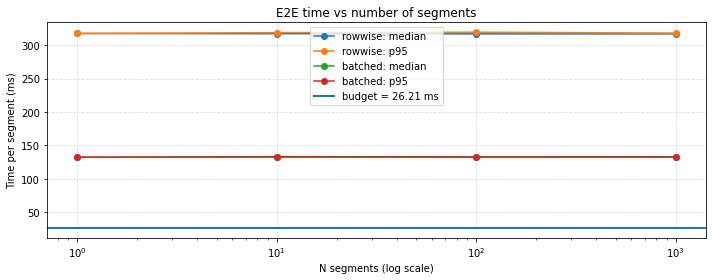

In [28]:
plt.figure(figsize=(10, 4))

for mode in ["rowwise", "batched"]:
    d = dfN[dfN["mode"] == mode].sort_values("N")
    plt.plot(d["N"], d["e2e_median_ms"], marker="o", label=f"{mode}: median")
    plt.plot(d["N"], d["e2e_p95_ms"], marker="o", label=f"{mode}: p95")

plt.axhline(budget_ms, linewidth=2, label=f"budget = {budget_ms:.2f} ms")
plt.xscale("log")
plt.xlabel("N segments (log scale)")
plt.ylabel("Time per segment (ms)")
plt.title("E2E time vs number of segments")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()


breakdown вкладов (LOAD / preprocess / forward / post) для большого N

Берём самый большой N и строим stacked-bar для median и p95.

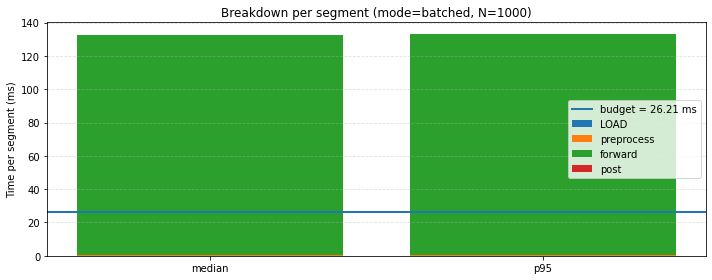

In [29]:
N_best = dfN["N"].max()
mode = "batched"  # поменяй на "batched" чтобы сравнить c rowwise
idxs = rng.choice(n_total_segments, size=int(N_best), replace=False)

t = bench_N_segments(filterbank_file, idxs, mode=mode, threshold=thr, warmup=3)

def perc_ms(x, q):
    return float(np.percentile(np.asarray(x)*1e3, q))

# median/p95 по компонентам
parts = ["load", "preprocess", "forward", "post"]
med = {p: perc_ms(t[p], 50) for p in parts}
p95 = {p: perc_ms(t[p], 95) for p in parts}

labels = ["median", "p95"]
x = np.arange(2)

load_vals = [med["load"], p95["load"]]
pre_vals  = [med["preprocess"], p95["preprocess"]]
fwd_vals  = [med["forward"], p95["forward"]]
post_vals = [med["post"], p95["post"]]

plt.figure(figsize=(10, 4))
plt.bar(x, load_vals, label="LOAD")
plt.bar(x, pre_vals, bottom=load_vals, label="preprocess")
bottom2 = [load_vals[i] + pre_vals[i] for i in range(2)]
plt.bar(x, fwd_vals, bottom=bottom2, label="forward")
bottom3 = [bottom2[i] + fwd_vals[i] for i in range(2)]
plt.bar(x, post_vals, bottom=bottom3, label="post")

plt.axhline(budget_ms, linewidth=2, label=f"budget = {budget_ms:.2f} ms")
plt.xticks(x, labels)
plt.ylabel("Time per segment (ms)")
plt.title(f"Breakdown per segment (mode={mode}, N={int(N_best)})")
plt.grid(True, axis="y", ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

total_med = sum(med.values())
total_p95 = sum(p95.values())



In [30]:
print(f"Share INFER (median) = {(med['preprocess']+med['forward']+med['post'])/total_med:.2%}")
print(f"Share INFER (p95)    = {(p95['preprocess']+p95['forward']+p95['post'])/total_p95:.2%}")

Share INFER (median) = 99.91%
Share INFER (p95)    = 99.90%


“стабильность” по длинному прогону (rolling mean)

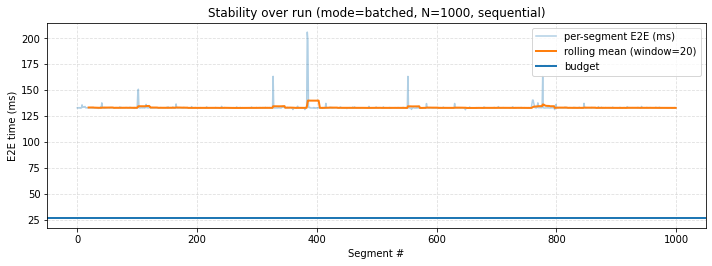

In [31]:
N_big = int(N_best)
mode = "batched"  # rowwise или "batched"
idxs = np.arange(N_big, dtype=int)  # sequential (как поток)

t_big = bench_N_segments(filterbank_file, idxs, mode=mode, threshold=thr, warmup=3)
e2e_ms = t_big["e2e"] * 1e3

window = max(5, N_big // 50)  # ~2% окна
rolling = pd.Series(e2e_ms).rolling(window=window).mean()

plt.figure(figsize=(10, 3.8))
plt.plot(e2e_ms, alpha=0.35, label="per-segment E2E (ms)")
plt.plot(rolling, linewidth=2, label=f"rolling mean (window={window})")
plt.axhline(budget_ms, linewidth=2, label="budget")
plt.xlabel("Segment #")
plt.ylabel("E2E time (ms)")
plt.title(f"Stability over run (mode={mode}, N={N_big}, sequential)")
plt.grid(True, ls="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()
